---
title: Iberian station data
subtitle: Real daily surface-air-temperature records from the Copernicus CDS
short_title: Station data
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-05
keywords:
  - in-situ observations
  - surface air temperature
  - Copernicus CDS
  - Iberia
abstract: |
  Everything in this curriculum is built on real station data: daily
  near-surface air temperature from the Copernicus Climate Data Store in-situ
  land archive, across the Iberian peninsula and its surroundings. This notebook
  introduces that dataset — where it comes from, how the shared loader cleans it,
  what the station network looks like, and how the daily series behave through
  the seasons — so later notebooks can focus on the modelling.
---

# Iberian station data

We are going to model **temperature extremes in space**, and that starts with
good data. This notebook simply *looks at the data*: the station network, the
daily records, and their seasonal behaviour. No modelling yet.

## Background

The data is the Copernicus Climate Data Store (CDS) product
[**in-situ observations of surface land meteorological variables**](https://cds.climate.copernicus.eu/datasets/insitu-observations-surface-land)
(DOI [10.24381/cds.cf5f3bac](https://doi.org/10.24381/cds.cf5f3bac)) — daily
near-surface air temperature collated and quality-controlled by C3S together
with NOAA's National Centers for Environmental Information, the WMO World Data
Centre for meteorology.

The shared loader `spatial_extremes.data` does the fetching (via
[`xrreader`](https://github.com/jejjohnson/xrreader)) and cleaning: it restricts to
the Iberian bounding box, keeps **1995–2020**, converts Kelvin to °C, retains
only quality-flag-0 observations, and reduces each station-day to its **daily
maximum**. When the real CDS cache is absent it transparently falls back to a
deterministic synthetic series, so the notebooks always run.

## Setup

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

from spatial_extremes import data
from spatial_extremes.places import country_from_id, station_label
from spatial_extremes.viz import iberia_axes, scatter_field, mark_points, mark_star

In [3]:
df, is_real = data.load_station_daily()
print("source:", "REAL CDS cache" if is_real else "synthetic fallback")
print(f"rows: {len(df):,}  |  stations: {df.station_id.nunique()}")
print(f"date range: {df.time.min().date()} -> {df.time.max().date()}")
df.head()

source: REAL CDS cache
rows: 6,823,690  |  stations: 198
date range: 1896-11-01 -> 2026-01-11


,station_id,time,lon,lat,value
0,SP000003195,1920-01-01,-3.678,40.412,11.9
1,SP000003195,1920-01-01,-3.678,40.412,8.8
2,SP000003195,1920-01-02,-3.678,40.412,11.0
3,SP000003195,1920-01-02,-3.678,40.412,2.6
4,SP000003195,1920-01-03,-3.678,40.412,2.4


## The station network

Each station is a GHCN/WMO-coded site with a longitude, latitude and a daily
temperature series. We decode the country prefix and tag each with its nearest
city for readability, then map the network — coloured by each station's **mean
daily-maximum temperature**, which already shows the warm south / cool
north-and-altitude gradient.

In [4]:
stations = df.groupby("station_id").agg(
    lon=("lon", "first"), lat=("lat", "first"),
    mean_tmax=("value", "mean"), n_days=("value", "size"),
)
stations["country"] = [country_from_id(s) for s in stations.index]
print("stations by country:")
print(stations["country"].value_counts().to_string())

stations by country:
country
Spain    198


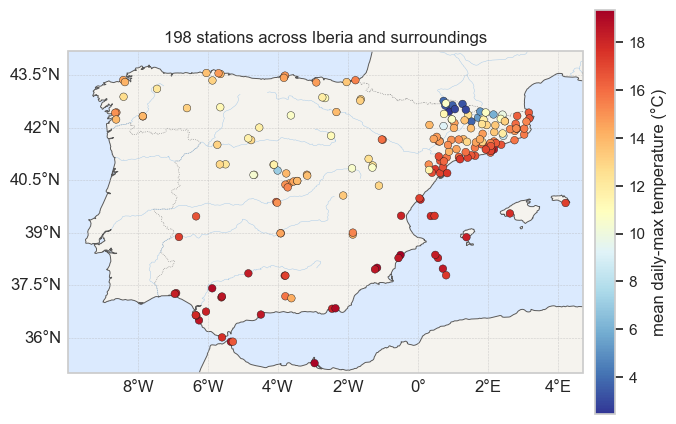

In [5]:
ax = iberia_axes(figsize=(8, 7))
scatter_field(ax, stations["lon"], stations["lat"], stations["mean_tmax"],
              label="mean daily-max temperature (°C)", cmap="RdYlBu_r", s=30)
ax.set_title(f"{len(stations)} stations across Iberia and surroundings")
plt.show()

## A look at the daily records

Three stations along a south-to-north transect show the shared seasonal cycle
and the cooler, more variable records further north / inland. We plot daily
maxima as a scatter of observations rather than a line — it reads more honestly
for irregular, gappy station data.

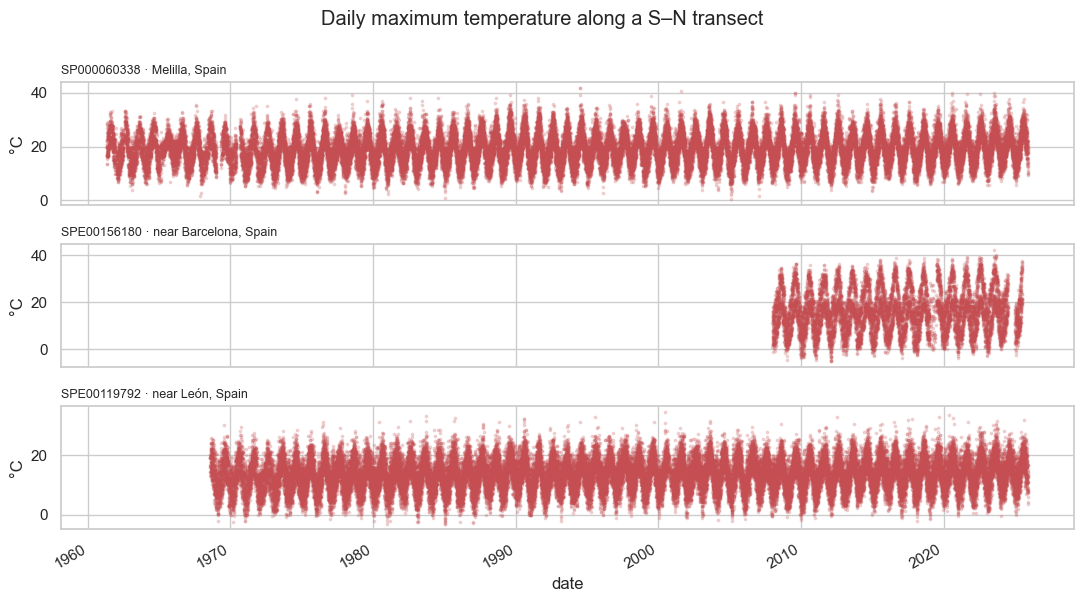

In [6]:
transect = stations.sort_values("lat").iloc[[0, len(stations) // 2, -1]]
fig, axes = plt.subplots(len(transect), 1, figsize=(11, 6), sharex=True)
for ax, (sid, row) in zip(axes, transect.iterrows()):
    s = df[df.station_id == sid].sort_values("time")
    ax.scatter(s.time, s.value, s=3, alpha=0.2, color="#C44E52")
    ax.set_ylabel("°C")
    ax.set_title(station_label(sid, row.lon, row.lat), fontsize=9, loc="left")
axes[-1].set_xlabel("date")
fig.suptitle("Daily maximum temperature along a S–N transect", y=1.0)
fig.autofmt_xdate(rotation=30)
fig.tight_layout()
plt.show()

## The seasonal cycle

Pooling every station-day and grouping by month makes the seasonal swing
explicit — the single biggest source of variation in the raw series, and the
reason the next notebook reduces each year to a single block maximum.

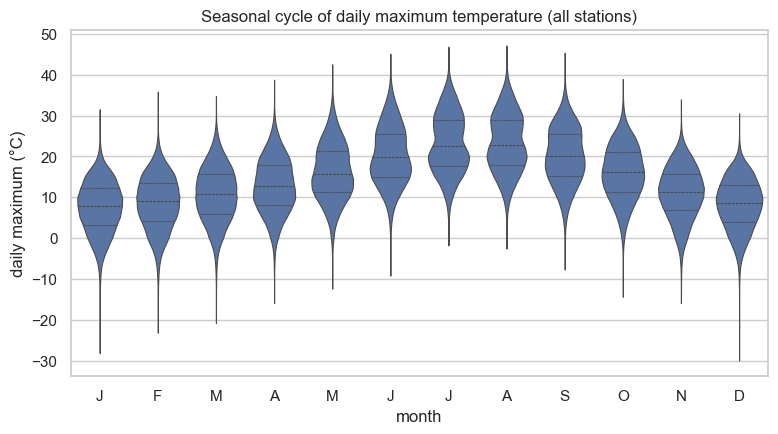

In [7]:
dd = df.copy()
dd["month"] = dd.time.dt.month
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.violinplot(data=dd, x="month", y="value", ax=ax, inner="quartile",
               color="#4C72B0", linewidth=0.8, cut=0)
ax.set(xlabel="month", ylabel="daily maximum (°C)",
       title="Seasonal cycle of daily maximum temperature (all stations)")
ax.set_xticks(range(12), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
plt.show()

## Recap & where next

We have a clean, real, multi-decade network of daily maximum temperatures over
Iberia, dominated by a strong seasonal cycle. In
[](../01_evt_foundations/01_block_maxima.ipynb) we reduce these daily records to
**block maxima** — the hottest day per block — and see how the choice of block
length (week, month, season, year) shapes what we get.